# 01 — Exploratory Data Analysis
World Happiness Report 2005-2025

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_processing import load_raw_data, preprocess, save_splits, FEATURES, TARGET
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 
1. Load Data

In [2]:
df = load_raw_data('../data/raw/world_happiness_report_2005_2025.csv')
print(df.shape)
df.head()

Loaded 2,116 rows | Columns: ['year', 'rank_in_year', 'country', 'happiness_score', 'lower_whisker', 'upper_whisker', 'explained_log_gdp_per_capita', 'explained_social_support', 'explained_healthy_life_expectancy', 'explained_freedom', 'explained_generosity', 'explained_corruption', 'dystopia_plus_residual']
(2116, 13)


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Basic Info

In [3]:
print(f'Years: {df["year"].min()} - {df["year"].max()}')
print(f'Countries: {df["country"].nunique()}')
print(f'\nMissing values:')
print(df.isnull().sum())

Years: 2011 - 2025
Countries: 168

Missing values:
year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64


## 3. Happiness Score Distribution

Removed 0 duplicates
Final dataset: 2,116 rows
Years: 2011 - 2025
Countries: 168


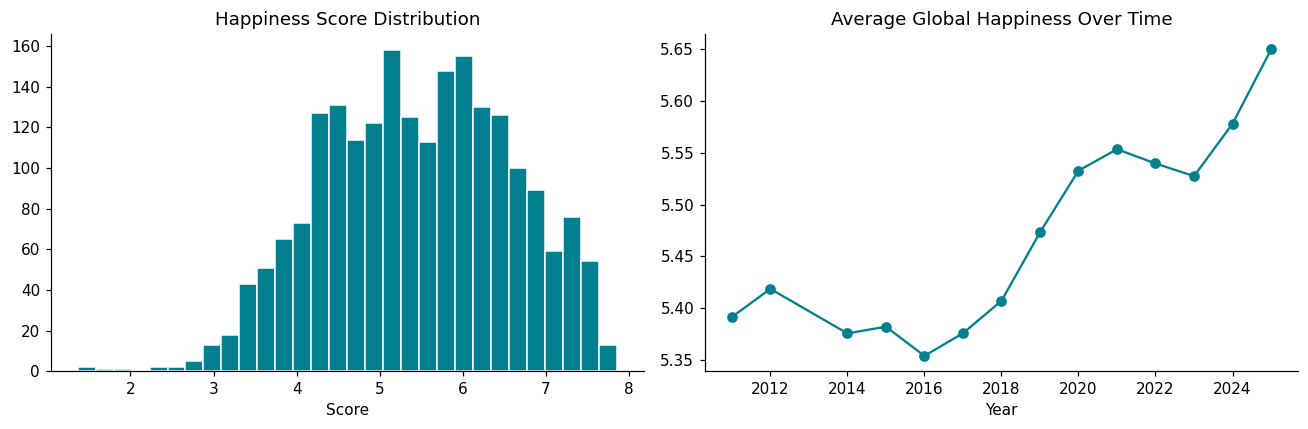

In [4]:
df_clean = preprocess(df)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['happiness_score'], bins=30, color='#028090', edgecolor='white')
axes[0].set_title('Happiness Score Distribution')
axes[0].set_xlabel('Score')
axes[0].spines[['top','right']].set_visible(False)
df_clean.groupby('year')['happiness_score'].mean().plot(ax=axes[1], color='#028090', marker='o')
axes[1].set_title('Average Global Happiness Over Time')
axes[1].set_xlabel('Year')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Top & Bottom Countries (Latest Year)

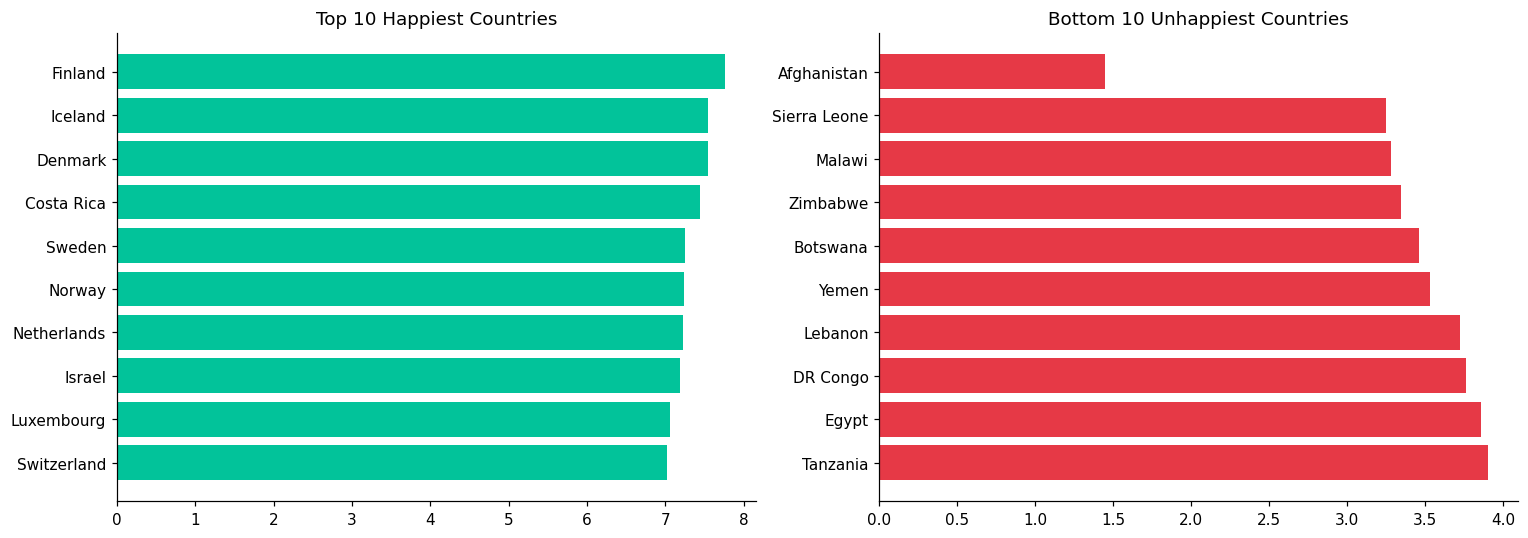

In [5]:
latest = df_clean[df_clean['year'] == df_clean['year'].max()]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top10 = latest.nlargest(10, 'happiness_score')
axes[0].barh(top10['country'], top10['happiness_score'], color='#02C39A')
axes[0].set_title('Top 10 Happiest Countries')
axes[0].invert_yaxis()
axes[0].spines[['top','right']].set_visible(False)
bottom10 = latest.nsmallest(10, 'happiness_score')
axes[1].barh(bottom10['country'], bottom10['happiness_score'], color='#E63946')
axes[1].set_title('Bottom 10 Unhappiest Countries')
axes[1].invert_yaxis()
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

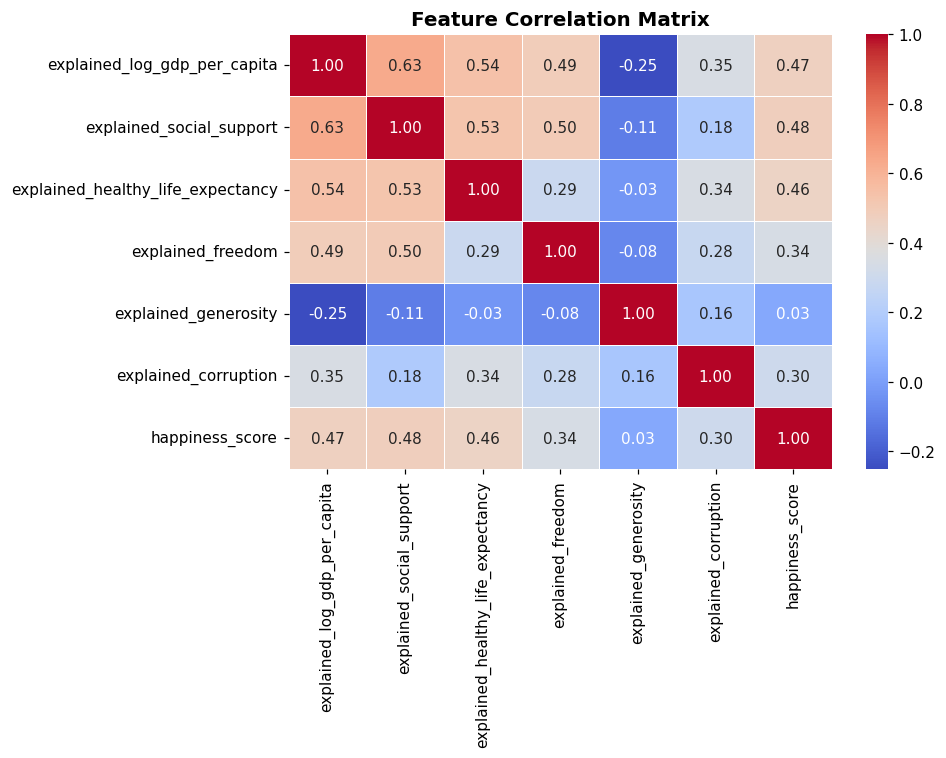

In [6]:
corr_cols = FEATURES + [TARGET]
corr = df_clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Save Splits

In [7]:
save_splits(df_clean, '../data/processed')
print('Done! Ready for modeling.')

Train: 1,692 | Test: 424
Saved to ../data/processed/
Done! Ready for modeling.
